In [1]:
%load_ext jupyter_black

In [7]:
import torch
import torch.nn as nn
import torchvision
from torchvision.datasets.vision import VisionDataset
import torchvision.transforms as transforms
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from einops import rearrange

# Data preparation
We first need to prepare the data set: download the data, split train/val set and do normalisation. This part is taken from https://teaching.pages.centralesupelec.fr/deeplearning-lectures-build/00-pytorch-fashionMnist.html

In [3]:
# 1. Get the data
# Change path accordingly
dataset_dir = "/home/mfauvel/Documents/Data/FashionMNIST"
train_valid_dataset = torchvision.datasets.FashionMNIST(
    root=dataset_dir, train=True, transform=None, download=True
)
train_dataset, valid_dataset = torch.utils.data.dataset.random_split(
    train_valid_dataset, [0.8, 0.2]
)
test_dataset = torchvision.datasets.FashionMNIST(
    root=dataset_dir, transform=None, train=False
)

In [4]:
# 2. Compute the normalization
class Scaler(torch.nn.Module):
    def __init__(self):
        self.mean_: torch.Tensor | None = None
        self.std_: torch.Tensor | None = None
        self.toTensor = transforms.ToTensor()

    def fit(self, dataset) -> None:
        if self.mean_ is None:
            self.mean_ = torch.zeros_like(self.toTensor(dataset[0][0]))
            self.std_ = torch.zeros_like(self.toTensor(dataset[0][0]))

        # Mean
        for img, _ in dataset:
            self.mean_ += self.toTensor(img)
        self.mean_ /= len(dataset)

        # Std
        for img, _ in dataset:
            self.std_ += (self.mean_ - self.toTensor(img)) ** 2
        self.std_ /= len(dataset)
        self.std_ = torch.sqrt(self.std_)
        self.std_[self.std_ == 0] = 1

    def __call__(self, X: torch.Tensor) -> torch.Tensor:
        assert X.shape[-3:] == self.mean_.shape
        return (X - self.mean_) / self.std_

    def inverse_transform(self, X: torch.Tensor) -> torch.Tensor:
        assert X.shape[-3:] == self.mean_.shape
        return X * self.std_ + self.mean_


scaler = Scaler()
scaler.fit(train_dataset)

In [5]:
# 3. Prepare pytorch dataset
class DatasetTransformer(torch.utils.data.Dataset):
    def __init__(self, base_dataset, transform):
        self.base_dataset = base_dataset
        self.transform = transform

    def __getitem__(self, index):
        img, target = self.base_dataset[index]
        return self.transform(img), target

    def __len__(self):
        return len(self.base_dataset)


data_transforms = transforms.Compose([transforms.ToTensor(), scaler])
train_dataset = DatasetTransformer(train_dataset, data_transforms)
valid_dataset = DatasetTransformer(valid_dataset, data_transforms)
test_dataset = DatasetTransformer(test_dataset, data_transforms)

In [6]:
# 4. Prepare data loader
num_threads = 4  # Loading the dataset is using 4 CPU threads
batch_size = 512  # Using minibatches of 512 samples

train_loader = torch.utils.data.DataLoader(
    dataset=train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_threads
)

valid_loader = torch.utils.data.DataLoader(
    dataset=valid_dataset, batch_size=batch_size, shuffle=False, num_workers=num_threads
)

test_loader = torch.utils.data.DataLoader(
    dataset=test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_threads
)

# Model definition

In [10]:
class MLPClassificationModel(nn.Module):
    def __init__(self, n_features: int, n_classes: int):
        super(MLPClassificationModel, self).__init__()
        self.n_features = n_features
        self.n_classes = n_classes
        # TODO
        self.softmax = nn.Softmax(dim=1)

    def forward(self, X: torch.Tensor) -> torch.Tensor:
        X = rearrange(
            X, "b c h w -> b (c h w)"
        )  # reshape the data as a long vector [batch_size, n_feature]
        y = self.layers(X)
        return y

    def predict_proba(self, X: torch.Tensor) -> torch.Tensor:
        y = self.forward(X)
        p = self.softmax(y)
        return p

    def predict(self, X: torch.Tensor) -> torch.Tensor:
        p = self.forward(X)
        c = torch.argmax(p, dim=1)
        return c

# Training the model

In [11]:
n_epochs = 50
learning_rate = 0.001
model = MLPClassificationModel(28 * 28, 10)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

train_set_len = len(train_loader)
val_set_len = len(valid_loader)
train_loss, val_loss = [], []

for epoch in range(n_epochs):
    model.train()
    accu = 0.0

    for X_, y_ in train_loader:
        # Forward pass
        y_hat = model(X_)
        loss = loss_fn(y_hat, y_)
        accu += loss.item()

        # backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    train_loss.append(accu / train_set_len)

    # Validation - no gradient & eval mode
    model.eval()
    accu = 0.0
    with torch.no_grad():
        for X_, y_ in valid_loader:
            # Forward pass
            y_hat = model(X_)
            loss = loss_fn(y_hat, y_)
            accu += loss.item()
        val_loss.append(accu / val_set_len)

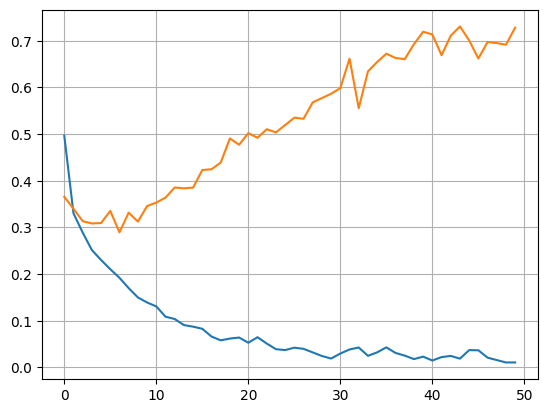

In [12]:
plt.plot(train_loss)
plt.plot(val_loss)
plt.grid()

In [13]:
model.eval()
acc = 0.0
with torch.no_grad():
    for X_, y_ in test_loader:
        y_hat = model.predict(X_)
        acc += (y_ == y_hat).sum().item()
    acc /= len(test_dataset)
print(acc)

0.8953


# To Do
- Implement dropout and train again.
- Implement a check to save the best model w.r.t the validation loss and compare the accuracy of the "best" model with the "last" model.